Clone git repo to bring existing files into runtime

In [1]:
!git clone https://github.com/realaaravdas/fs-5-software-intro-projects.git

Cloning into 'fs-5-software-intro-projects'...
remote: Enumerating objects: 171, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 171 (delta 35), reused 29 (delta 29), pack-reused 128 (from 1)
Receiving objects: 100% (171/171), 450.05 KiB | 26.47 MiB/s, done.
Resolving deltas: 100% (69/69), done.


In [2]:
%cd fs-5-software-intro-projects/auto

/content/fs-5-software-intro-projects/auto


Initialise and test CD

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pid_template import make_car, update, calculate_desired_acceleration, acceleration_to_throttle_percentage

print(calculate_desired_acceleration(make_car(), 0.5))

(10.0, 20.0)


Create Loop and Generate Data


In [4]:
# Set base PID values

K_P = 0.5
K_I = 0.0
K_D = 0.0

RDM = 30

STEPS = 3000    # Define amount of steps (pts of data to run)

inputs = []
targets = []

Importing PyTorch into Colab Environment

In [5]:
import torch
from torch import nn

Generating Data Here vvv

In [6]:
np.random.seed(0)                      # repeatable randomness-- making it random, but repeatable for future re-runs
HOLD = 30                              # Sets how often the target changes to allow the model to see more situations
car = make_car(desired_v=20.0, dt=0.1)
inputs, targets = [], []

for step in range(STEPS):                                                       # Simulation loop
    if step % HOLD == 0:                                                        # Check if target should change
        car["desired_v"] = float(np.random.uniform(5, 40))                      # if target should change, change the target for PID (desired_v)

    a_des, error = calculate_desired_acceleration(car, K_P, K_I, K_D)           # run PID controller

    inputs.append([car["v"], car["desired_v"]])                                 # Capture what the controller saw
    targets.append([a_des])                                                     # Captyre what it decided

    update(car, acceleration_to_throttle_percentage(a_des))                     # advance the car based on throttle decided by PID controller

X = np.array(inputs, dtype=np.float32)                                          # plot Data (3000, 2)
y = np.array(targets, dtype=np.float32)                                         # Plot Data (3000, 1)
print(X.shape, y.shape)                # Print Data

(3000, 2) (3000, 1)


This plots the generated data from the PID controller. It shows the desired velocity (which changes with each 30 iterations, (or how many every hold =)), and how the velocity changes with that due to the PID controllers desired acceleration that is controlled by the throttle conversion

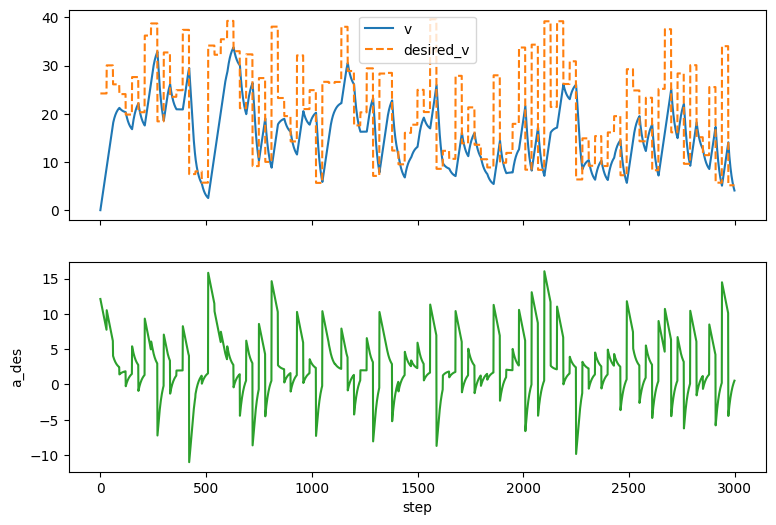

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(9, 6))                         # plots the data as 2 subplots for good looks
ax1.plot(X[:, 0], label="v"); ax1.plot(X[:, 1], "--", label="desired_v"); ax1.legend()
ax2.plot(y[:, 0], color="tab:green"); ax2.set_ylabel("a_des"); ax2.set_xlabel("step")
plt.show()

In [8]:
VMAX = 40.0                                                                     # To keep the training stable, inputs are scaled between 0 and 1
X_t = torch.tensor(X / VMAX, dtype=torch.float32)                               # vvv
y_t = torch.tensor(y, dtype=torch.float32)                                      # Wrapping as tensors for training

torch.manual_seed(42)                                                           # This portio divides the 3000 examples of data between training data
perm = torch.randperm(len(X_t))                                                 #   and testing data. 2400 for training and 600 for testing
n_train = int(0.8 * len(X_t))
X_train, y_train = X_t[perm[:n_train]], y_t[perm[:n_train]]
X_test,  y_test  = X_t[perm[n_train:]], y_t[perm[n_train:]]
print(X_train.shape, X_test.shape)    # (2400, 2) (600, 2)                      # just double checking that it shuffled things correclty (ignore this)

torch.Size([2400, 2]) torch.Size([600, 2])


Setting up for training the model

In [9]:
model = nn.Linear(in_features=2, out_features=1)                                # Creating 2 tuneable values that can be altered by the model
print(model.weight, model.bias)                                                 # printing random numbers to confirm prepared for training

Parameter containing:
tensor([[0.1110, 0.5444]], requires_grad=True) Parameter containing:
tensor([0.5301], requires_grad=True)


In [10]:
loss_fn = nn.MSELoss()                                                          # mean squared error (average of (prediction - truth))
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)                         # object will tune models values

This part of the code is that actual training of the model.  It first does a forward pass- a guess, and it measures how wrong of a guess it was. After that if figures out which direction to tune each value towards. Lastly it tunes each value very slightly

In [11]:
EPOCHS = 2000       # Defines how many cylces of training should go through, higher = more accurate
train_losses, test_losses = [], []        # creating the lists to save the loss curves in

for epoch in range(EPOCHS):
    model.train()
    y_pred = model(X_train)              # 1. guess
    loss = loss_fn(y_pred, y_train)      # 2. error calculate
    optimizer.zero_grad()                # 3. clear old sh&t
    loss.backward()                      # 4. compute new sh&t
    optimizer.step()                     # 5. update weights

    model.eval()
    with torch.inference_mode():                                                # Checking how the model does on test rows
        test_loss = loss_fn(model(X_test), y_test)

    train_losses.append(loss.item())                                            # Stores the losses are plain numbers, and print out every
    test_losses.append(test_loss.item())                                        #   200 epoch to see loss fall

    if epoch % 200 == 0:
        print(f"epoch {epoch:4d} | train {loss.item():9.5f} | test {test_loss.item():9.5f}")

epoch    0 | train  22.39407 | test  21.14596
epoch  200 | train   2.99942 | test   3.17282
epoch  400 | train   0.77516 | test   0.81904
epoch  600 | train   0.20674 | test   0.21833
epoch  800 | train   0.05525 | test   0.05834
epoch 1000 | train   0.01477 | test   0.01559
epoch 1200 | train   0.00395 | test   0.00417
epoch 1400 | train   0.00106 | test   0.00111
epoch 1600 | train   0.00028 | test   0.00030
epoch 1800 | train   0.00008 | test   0.00008


This is the loss curve-- it shows the loss over time, showing accuracy increase every epoch.

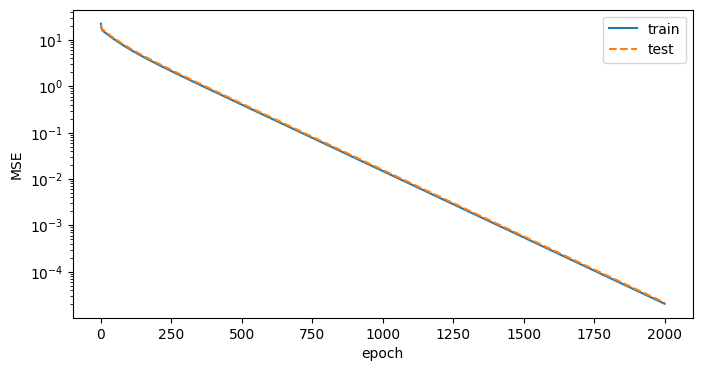

learned:  a_des = -0.4992*v +0.4997*desired_v -0.0054
expected: a_des = -0.5000*v +0.5000*desired_v +0.0000


In [12]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train"); plt.plot(test_losses, "--", label="test")
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("MSE"); plt.legend(); plt.show()

w = model.weight.detach().numpy().ravel() / VMAX
b = model.bias.item()
print(f"learned:  a_des = {w[0]:+.4f}*v {w[1]:+.4f}*desired_v {b:+.4f}")              # prints learned vs the formula PID
print(f"expected: a_des = {-K_P:+.4f}*v {K_P:+.4f}*desired_v +0.0000")

Running the trained model on test inputs to see the comparison with the PID output. Scatter plot hugs redline, showing accuracy

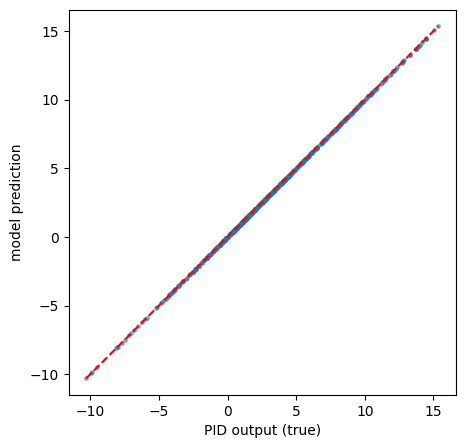

In [13]:
with torch.inference_mode():
    pred = model(X_test).numpy().ravel()
true = y_test.numpy().ravel()

plt.figure(figsize=(5, 5))
plt.scatter(true, pred, s=6, alpha=0.5)
lims = [true.min(), true.max()]
plt.plot(lims, lims, "r--")
plt.xlabel("PID output (true)"); plt.ylabel("model prediction"); plt.axis("equal"); plt.show()

Running the simulation using the model as the controller rather than the PID. Model will only hit 16 because it is only learning form P value, not the I or D value of the PID.

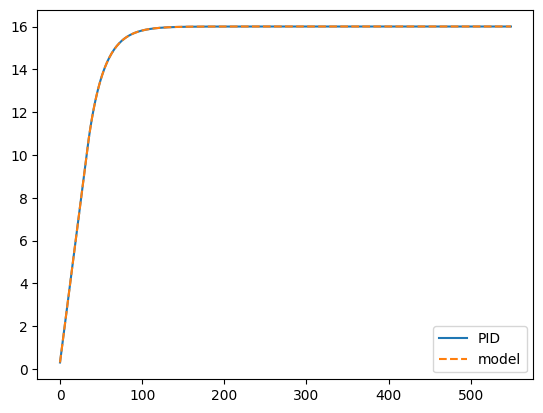

In [14]:
def model_accel(car):
    x = torch.tensor([[car["v"] / VMAX, car["desired_v"] / VMAX]], dtype=torch.float32)   # Wrapping the model to work as a controller
    with torch.inference_mode():
        return model(x).item()

def run(controller, steps=550, desired_v=20.0):                                 # Custom run fcn that will take model as controller
    c = make_car(desired_v=desired_v, dt=0.1); vs = []
    for _ in range(steps):
        update(c, acceleration_to_throttle_percentage(controller(c)))
        vs.append(c["v"])
    return vs

pid_v   = run(lambda c: calculate_desired_acceleration(c, K_P)[0])
model_v = run(model_accel)
plt.plot(pid_v, label="PID"); plt.plot(model_v, "--", label="model"); plt.legend(); plt.show()      # plot